<a href="https://colab.research.google.com/github/selim679/Backblaze-panne-disques-durs/blob/main/notebookbacklaze.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

salimfekihsalem_backblaze1_path = kagglehub.dataset_download('salimfekihsalem/backblaze1')
salimfekihsalem_backblaze_pkl1_path = kagglehub.dataset_download('salimfekihsalem/backblaze-pkl1')
salimfekihsalem_seq_30_path = kagglehub.dataset_download('salimfekihsalem/seq-30')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/salimfekihsalem/seq-30/test_seq30_look7.pkl
/kaggle/input/datasets/salimfekihsalem/seq-30/train_seq30_look7.pkl
/kaggle/input/datasets/salimfekihsalem/backblaze-pkl1/Lab1-2016-Q4-ST4000DM000.pkl
/kaggle/input/datasets/salimfekihsalem/backblaze-pkl1/Lab1-2017-Full-ST4000DM000.pkl
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-07-18.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-09-24.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-08-27.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-07-24.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-09-18.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-08-29.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-08-09.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-07-08.csv
/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017/2017-07-19

In [ ]:

import pandas as pd
import numpy as np
import os, gc
from tqdm import tqdm

MODEL    = 'ST4000DM000'
DATA_DIR = '/kaggle/working/data/'
os.makedirs(DATA_DIR, exist_ok=True)

PKL_TRAIN = DATA_DIR + 'Lab1-2017-Full-ST4000DM000.pkl'
PKL_TEST  = DATA_DIR + 'Lab1-2016-Q4-ST4000DM000.pkl'

folders_2017 = [
    '/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q1_2017',
    '/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q2_2017',
    '/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q3_2017',
    '/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q4_2017',
]
folders_2016_q4 = [
    '/kaggle/input/datasets/salimfekihsalem/backblaze1/data_Q4_2016',
]

def load_filtered_and_save(folders, pkl_path, model=MODEL):
    """Charge CSV un par un, filtre sur le modèle, sauvegarde en PKL."""

    # Colonnes à garder (métadonnées + SMART brutes uniquement)
    META = ['date', 'serial_number', 'model', 'capacity_bytes', 'failure']

    chunks = []
    total_rows = 0

    for folder in folders:
        if not os.path.exists(folder):
            print(f"⚠️  Manquant : {folder}")
            continue

        files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder) if f.endswith('.csv')
        ])
        print(f"\n📂 {os.path.basename(folder)} → {len(files)} fichiers")

        for file in tqdm(files):
            try:
                # 1. Lire seulement les colonnes nécessaires
                # D'abord récupère les colonnes disponibles
                cols_available = pd.read_csv(file, nrows=0).columns.tolist()

                # Garde META + toutes les colonnes smart_X_raw (pas normalized)
                smart_raw = [c for c in cols_available
                             if 'smart_' in c and '_normalized' not in c]
                cols_to_read = META + smart_raw
                cols_to_read = [c for c in cols_to_read if c in cols_available]

                # 2. Lire avec filtre colonnes
                tmp = pd.read_csv(file, usecols=cols_to_read, low_memory=False)

                # 3. Filtrer sur le modèle
                tmp = tmp[tmp['model'] == model].copy()

                if tmp.empty:
                    continue

                # 4. Réduire la mémoire immédiatement
                for col in tmp.select_dtypes('float64').columns:
                    tmp[col] = tmp[col].astype('float32')
                for col in tmp.select_dtypes('int64').columns:
                    tmp[col] = tmp[col].astype('int32')

                total_rows += len(tmp)
                chunks.append(tmp)
                del tmp

            except Exception as e:
                print(f"❌ {file}: {e}")

        # Libérer après chaque quarter
        gc.collect()

    if not chunks:
        raise ValueError("Aucune donnée !")

    print(f"\n🔗 Concaténation de {len(chunks)} chunks ({total_rows} lignes)...")
    df = pd.concat(chunks, ignore_index=True)
    del chunks
    gc.collect()

    ram = df.memory_usage(deep=True).sum() / 1e9
    print(f"✅ Shape : {df.shape}  |  RAM : {ram:.2f} GB")
    print(f"   Pannes : {df['failure'].sum()}")

    print(f"💾 Sauvegarde → {pkl_path}")
    df.to_pickle(pkl_path)
    print("✅ PKL sauvegardé !")

    return df

# --- Génération TRAIN ---
print("=" * 50)
print("GÉNÉRATION TRAIN (2017)")
print("=" * 50)
df = load_filtered_and_save(folders_2017, PKL_TRAIN)

# --- Génération TEST ---
print("\n" + "=" * 50)
print("GÉNÉRATION TEST (2016 Q4)")
print("=" * 50)
df_t = load_filtered_and_save(folders_2016_q4, PKL_TEST)

print("\n✅ TERMINÉ")
print(f"Fichiers générés :")
print(f"  {PKL_TRAIN}  ({os.path.getsize(PKL_TRAIN)/1e6:.1f} MB)")
print(f"  {PKL_TEST}   ({os.path.getsize(PKL_TEST)/1e6:.1f} MB)")

GÉNÉRATION TRAIN (2017)

📂 data_Q1_2017 → 90 fichiers


100%|██████████| 90/90 [00:44<00:00,  2.01it/s]



📂 data_Q2_2017 → 91 fichiers


100%|██████████| 91/91 [00:49<00:00,  1.84it/s]



📂 data_Q3_2017 → 92 fichiers


...


📂 data_Q4_2017 → 92 fichiers


100%|██████████| 92/92 [00:54<00:00,  1.70it/s]



🔗 Concaténation de 361 chunks (12237899 lignes)...
✅ Shape : (12237899, 50)  |  RAM : 5.04 GB
   Pannes : 1058
💾 Sauvegarde → /kaggle/working/data/Lab1-2017-Full-ST4000DM000.pkl
✅ PKL sauvegardé !

GÉNÉRATION TEST (2016 Q4)

📂 data_Q4_2016 → 92 fichiers


100%|██████████| 92/92 [00:47<00:00,  1.92it/s]



🔗 Concaténation de 92 chunks (3196552 lignes)...
✅ Shape : (3196552, 50)  |  RAM : 1.32 GB
   Pannes : 234
💾 Sauvegarde → /kaggle/working/data/Lab1-2016-Q4-ST4000DM000.pkl
✅ PKL sauvegardé !

✅ TERMINÉ
Fichiers générés :
  /kaggle/working/data/Lab1-2017-Full-ST4000DM000.pkl  (3122.0 MB)
  /kaggle/working/data/Lab1-2016-Q4-ST4000DM000.pkl   (812.0 MB)


In [ ]:
# ============================================================
# CHARGEMENT RAPIDE (après upload des PKL)
# ============================================================
import pandas as pd

df   = pd.read_pickle('/kaggle/input/datasets/salimfekihsalem/backblaze-pkl1/Lab1-2017-Full-ST4000DM000.pkl')
df_t = pd.read_pickle('/kaggle/input/datasets/salimfekihsalem/backblaze-pkl1/Lab1-2016-Q4-ST4000DM000.pkl')

print("TRAIN :", df.shape,   "| Pannes :", df['failure'].sum())
print("TEST  :", df_t.shape, "| Pannes :", df_t['failure'].sum())

TRAIN : (12237899, 50) | Pannes : 1058
TEST  : (3196552, 50) | Pannes : 234


In [ ]:
df.head()

,date,serial_number,model,capacity_bytes,failure,smart_1_raw,smart_2_raw,smart_3_raw,smart_4_raw,smart_5_raw,...,smart_225_raw,smart_226_raw,smart_240_raw,smart_241_raw,smart_242_raw,smart_250_raw,smart_251_raw,smart_252_raw,smart_254_raw,smart_255_raw
0,2017-01-01,Z305B2QN,ST4000DM000,-2122489856,0,58173272.0,NaN,0.0,8.0,0.0,...,NaN,NaN,8947.0,3.078054e+10,8.290869e+09,NaN,NaN,NaN,NaN,NaN
1,2017-01-01,Z302A0YH,ST4000DM000,-2122489856,0,75626904.0,NaN,0.0,19.0,0.0,...,NaN,NaN,16788.0,2.164812e+10,1.620139e+11,NaN,NaN,NaN,NaN,NaN
2,2017-01-01,Z305BT0W,ST4000DM000,-2122489856,0,48893128.0,NaN,0.0,7.0,0.0,...,NaN,NaN,7771.0,2.616829e+10,1.589215e+10,NaN,NaN,NaN,NaN,NaN
3,2017-01-01,Z302A0YE,ST4000DM000,-2122489856,0,192617016.0,NaN,0.0,12.0,0.0,...,NaN,NaN,17308.0,2.126106e+10,2.363861e+11,NaN,NaN,NaN,NaN,NaN
4,2017-01-01,Z302PGH8,ST4000DM000,-2122489856,0,83211536.0,NaN,0.0,20.0,0.0,...,NaN,NaN,13560.0,1.619163e+10,7.198671e+10,NaN,NaN,NaN,NaN,NaN


In [ ]:

def analyze_columns(df, keyword='smart'):
    """
    Analyse toutes les colonnes contenant un mot-clé.
    Retourne un DataFrame avec les statistiques de chaque colonne.
    """
    # Sélectionner uniquement les colonnes contenant le mot-clé
    smart_cols = [c for c in df.columns if keyword in c.lower()]

    results = []
    for col in smart_cols:
        n_unique = df[col].nunique(dropna=True)
        col_min  = df[col].min(skipna=True)
        col_max  = df[col].max(skipna=True)
        n_nan    = df[col].isna().sum()

        is_constant = (n_unique <= 1) or (col_min == col_max)

        results.append({
            'colonne'      : col,
            'n_unique'     : n_unique,
            'min'          : col_min,
            'max'          : col_max,
            'n_nan'        : n_nan,
            'est_constante': is_constant
        })

    return pd.DataFrame(results)

# --- Analyse ---
print("Analyse des colonnes SMART...")
col_stats = analyze_columns(df, keyword='smart')

# Listes constantes vs informatives
const_cols = col_stats[col_stats['est_constante']]['colonne'].tolist()
info_cols  = col_stats[~col_stats['est_constante']]['colonne'].tolist()

print(f"\n📊 Colonnes SMART totales    : {len(col_stats)}")
print(f"   Colonnes CONSTANTES       : {len(const_cols)}")
print(f"   Colonnes INFORMATIVES     : {len(info_cols)}")
print(f"\nColonnes constantes : {const_cols}")
print(f"\nColonnes informatives : {info_cols}")

Analyse des colonnes SMART...

📊 Colonnes SMART totales    : 45
   Colonnes CONSTANTES       : 24
   Colonnes INFORMATIVES     : 21

Colonnes constantes : ['smart_2_raw', 'smart_3_raw', 'smart_8_raw', 'smart_10_raw', 'smart_11_raw', 'smart_13_raw', 'smart_15_raw', 'smart_22_raw', 'smart_191_raw', 'smart_195_raw', 'smart_196_raw', 'smart_200_raw', 'smart_201_raw', 'smart_220_raw', 'smart_222_raw', 'smart_223_raw', 'smart_224_raw', 'smart_225_raw', 'smart_226_raw', 'smart_250_raw', 'smart_251_raw', 'smart_252_raw', 'smart_254_raw', 'smart_255_raw']

Colonnes informatives : ['smart_1_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_9_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']


In [ ]:
analyze_columns(df, keyword='smart')

,colonne,n_unique,min,max,n_nan,est_constante
0,smart_1_raw,10052895,0.0,2.441406e+08,202,False
1,smart_2_raw,0,NaN,NaN,12237899,True
2,smart_3_raw,1,0.0,0.000000e+00,202,True
3,smart_4_raw,210,1.0,1.506000e+03,202,False
4,smart_5_raw,768,0.0,5.324800e+04,202,False
5,smart_7_raw,12096941,2.0,2.814717e+14,202,False
6,smart_8_raw,0,NaN,NaN,12237899,True
7,smart_9_raw,39782,0.0,3.991900e+04,202,False
8,smart_10_raw,1,0.0,0.000000e+00,202,True
9,smart_11_raw,0,NaN,NaN,12237899,True


In [ ]:
analyze_columns(df, keyword='')

,colonne,n_unique,min,max,n_nan,est_constante
0,date,361,2017-01-01,2017-12-31,0,False
1,serial_number,35189,S3000A9T,Z307Y2X9,0,False
2,model,1,ST4000DM000,ST4000DM000,0,True
3,capacity_bytes,3,-2122489856,-1,0,False
4,failure,2,0,1,0,False
5,smart_1_raw,10052895,0.0,244140608.0,202,False
6,smart_2_raw,0,NaN,NaN,12237899,True
7,smart_3_raw,1,0.0,0.0,202,True
8,smart_4_raw,210,1.0,1506.0,202,False
9,smart_5_raw,768,0.0,53248.0,202,False


In [ ]:

print(f"Dimensions AVANT suppression : {df.shape}")

df   = df.drop(columns=const_cols, errors='ignore')
df_t = df_t.drop(columns=const_cols, errors='ignore')

print(f"Dimensions APRÈS suppression : {df.shape}")
print(f"Colonnes supprimées          : {len(const_cols)}")

# Vérification : aucune variabilité dans les colonnes supprimées
print("\n Vérification des colonnes supprimées (toutes doivent être constantes) :")
print(col_stats[col_stats['est_constante']][['colonne','n_unique','min','max']].to_string(index=False))

Dimensions AVANT suppression : (12237899, 50)
Dimensions APRÈS suppression : (12237899, 26)
Colonnes supprimées          : 24

 Vérification des colonnes supprimées (toutes doivent être constantes) :
      colonne  n_unique  min  max
  smart_2_raw         0  NaN  NaN
  smart_3_raw         1  0.0  0.0
  smart_8_raw         0  NaN  NaN
 smart_10_raw         1  0.0  0.0
 smart_11_raw         0  NaN  NaN
 smart_13_raw         0  NaN  NaN
 smart_15_raw         0  NaN  NaN
 smart_22_raw         0  NaN  NaN
smart_191_raw         1  0.0  0.0
smart_195_raw         0  NaN  NaN
smart_196_raw         0  NaN  NaN
smart_200_raw         0  NaN  NaN
smart_201_raw         0  NaN  NaN
smart_220_raw         0  NaN  NaN
smart_222_raw         0  NaN  NaN
smart_223_raw         0  NaN  NaN
smart_224_raw         0  NaN  NaN
smart_225_raw         0  NaN  NaN
smart_226_raw         0  NaN  NaN
smart_250_raw         0  NaN  NaN
smart_251_raw         0  NaN  NaN
smart_252_raw         0  NaN  NaN
smart_254_raw     

In [ ]:
# ============================================================
# SECTION 2.3 — Nettoyage et sélection finale
# ============================================================

import gc

# ---- ÉTAPE 1 : Supprimer colonnes entièrement vides --------
before = df.shape[1]
df   = df.dropna(axis=1, how='all')
df_t = df_t.dropna(axis=1, how='all')
print(f"Colonnes entièrement vides supprimées : {before - df.shape[1]}")

# ---- ÉTAPE 2 : Supprimer lignes avec valeurs critiques manquantes ----
critical_cols = ['date', 'serial_number', 'failure']
before = len(df)
df   = df.dropna(subset=critical_cols)
df_t = df_t.dropna(subset=critical_cols)
print(f"Lignes supprimées (valeurs critiques manquantes) : {before - len(df)}")

# ---- ÉTAPE 3 : Colonnes avec valeurs manquantes restantes ----
nan_cols = df.columns[df.isna().any()].tolist()
print(f"\nColonnes avec NaN restants ({len(nan_cols)}) :")
print(df[nan_cols].isna().sum().sort_values(ascending=False).head(10))

# ---- ÉTAPE 4 : Remplacement des NaN par 0 ----
# Justification : les attributs SMART manquants signifient
# souvent que le disque ne supporte pas cet attribut → valeur neutre = 0
df[nan_cols]   = df[nan_cols].fillna(0)
df_t[nan_cols] = df_t[nan_cols].fillna(0)
print(f"\nNaN restants après remplacement : {df.isna().sum().sum()}")

# ---- ÉTAPE 5 : Séparation normaux / défaillants ----
df_failed  = df[df['failure'] == 1].copy()
df_normal  = df[df['failure'] == 0].copy()
print(f"\nDisques défaillants (failure=1) : {len(df_failed)} lignes")
print(f"Disques normaux    (failure=0) : {len(df_normal)} lignes")

Colonnes entièrement vides supprimées : 0
Lignes supprimées (valeurs critiques manquantes) : 0

Colonnes avec NaN restants (21) :
smart_1_raw      202
smart_4_raw      202
smart_5_raw      202
smart_7_raw      202
smart_9_raw      202
smart_12_raw     202
smart_183_raw    202
smart_184_raw    202
smart_187_raw    202
smart_188_raw    202
dtype: int64

NaN restants après remplacement : 0

Disques défaillants (failure=1) : 1058 lignes
Disques normaux    (failure=0) : 12236841 lignes


In [ ]:
# ---- ÉTAPE 6 & 7 : Sélection des variables SMART informatives ----
META_COLS = ['date', 'serial_number', 'failure']

# Variables brutes uniquement (pas normalized, déjà supprimées avant)
smart_raw_cols = [c for c in df.columns
                  if 'smart_' in c and '_normalized' not in c]

# Liste finale des colonnes
final_cols = META_COLS + smart_raw_cols

print(f"Colonnes métadonnées  : {len(META_COLS)}")
print(f"Colonnes SMART brutes : {len(smart_raw_cols)}")
print(f"Total colonnes finales: {len(final_cols)}")
print(f"\nColonnes SMART conservées : {smart_raw_cols}")

Colonnes métadonnées  : 3
Colonnes SMART brutes : 21
Total colonnes finales: 24

Colonnes SMART conservées : ['smart_1_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_9_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']


In [ ]:
# ---- ÉTAPE 8 & 9 : Appliquer les mêmes colonnes au test ----
# Garder seulement les colonnes finales
df   = df[[c for c in final_cols if c in df.columns]].copy()
df_t = df_t[[c for c in final_cols if c in df_t.columns]].copy()

# Vérification stricte
assert list(df.columns) == list(df_t.columns), "❌ Colonnes différentes entre train et test !"
print("✅ Colonnes identiques entre train et test")
print(f"   Ordre identique : {list(df.columns) == list(df_t.columns)}")

# ---- ÉTAPE 10 : Vérification finale ----
print(f"\n=== VÉRIFICATION FINALE ===")
print(f"TRAIN : {df.shape}  | NaN : {df.isna().sum().sum()} | Types : {df.dtypes.value_counts().to_dict()}")
print(f"TEST  : {df_t.shape} | NaN : {df_t.isna().sum().sum()} | Types : {df_t.dtypes.value_counts().to_dict()}")
display(df.head(3))

✅ Colonnes identiques entre train et test
   Ordre identique : True

=== VÉRIFICATION FINALE ===
TRAIN : (12237899, 24)  | NaN : 0 | Types : {dtype('float32'): 11, dtype('float64'): 10, dtype('O'): 2, dtype('int32'): 1}
TEST  : (3196552, 24) | NaN : 0 | Types : {dtype('float32'): 11, dtype('float64'): 10, dtype('O'): 2, dtype('int32'): 1}


,date,serial_number,failure,smart_1_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_12_raw,smart_183_raw,...,smart_190_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
0,2017-01-01,Z305B2QN,0,58173272.0,8.0,0.0,388359773.0,9195.0,8.0,0.0,...,24.0,0.0,33904.0,24.0,0.0,0.0,0.0,8947.0,3.078054e+10,8.290869e+09
1,2017-01-01,Z302A0YH,0,75626904.0,19.0,0.0,785458463.0,17043.0,19.0,0.0,...,19.0,0.0,39656.0,19.0,0.0,0.0,0.0,16788.0,2.164812e+10,1.620139e+11
2,2017-01-01,Z305BT0W,0,48893128.0,7.0,0.0,316494047.0,7857.0,7.0,0.0,...,30.0,0.0,9073.0,30.0,0.0,0.0,0.0,7771.0,2.616829e+10,1.589215e+10


In [ ]:
# ============================================================
# SECTION 2.4 — Sauvegarde en Pickle
# ============================================================

import os, time, gc

DATA_DIR = '/kaggle/working/data/'
os.makedirs(DATA_DIR, exist_ok=True)  # 🔥 FIX

PKL_TRAIN = DATA_DIR + 'Lab1-2017-Full-ST4000DM000.pkl'
PKL_TEST  = DATA_DIR + 'Lab1-2016-Q4-ST4000DM000.pkl'

print("💾 Sauvegarde TRAIN...")
df.to_pickle(PKL_TRAIN)

print("💾 Sauvegarde TEST...")
df_t.to_pickle(PKL_TEST)

# Vérification
df_check = pd.read_pickle(PKL_TRAIN)
print(f"\n✅ PKL rechargé : {df_check.shape} == {df.shape} → {df_check.shape == df.shape}")

# Temps de chargement
t0 = time.time()
pd.read_pickle(PKL_TRAIN)
print(f"⚡ Chargement PKL  : {time.time()-t0:.3f}s")

# Taille
print(f"\nTaille fichiers :")
print(f"  Train PKL : {os.path.getsize(PKL_TRAIN)/1e6:.1f} MB")
print(f"  Test  PKL : {os.path.getsize(PKL_TEST)/1e6:.1f} MB")

del df_check
gc.collect()

💾 Sauvegarde TRAIN...
💾 Sauvegarde TEST...

✅ PKL rechargé : (12237899, 24) == (12237899, 24) → True
⚡ Chargement PKL  : 2.333s

Taille fichiers :
  Train PKL : 1744.4 MB
  Test  PKL : 450.7 MB


0

In [ ]:

import pandas as pd
import numpy as np
import os, gc

DATA_DIR  = '/kaggle/working/data/'
PKL_TRAIN = DATA_DIR + 'Lab1-2017-Full-ST4000DM000.pkl'
PKL_TEST  = DATA_DIR + 'Lab1-2016-Q4-ST4000DM000.pkl'

# ÉTAPE 1 — Chargement
df   = pd.read_pickle(PKL_TRAIN)
df_t = pd.read_pickle(PKL_TEST)
print(f"Train chargé : {df.shape}")
print(f"Test  chargé : {df_t.shape}")

Train chargé : (12237899, 24)
Test  chargé : (3196552, 24)


In [ ]:
# ÉTAPE 2 & 3 — Supprimer colonnes 'normalized'
norm_cols = [c for c in df.columns if 'normalized' in c.lower()]
print(f"Colonnes 'normalized' trouvées : {len(norm_cols)}")
print(norm_cols)

df   = df.drop(columns=norm_cols, errors='ignore')
df_t = df_t.drop(columns=norm_cols, errors='ignore')
print(f"\nAprès suppression normalized → Train : {df.shape} | Test : {df_t.shape}")

Colonnes 'normalized' trouvées : 0
[]

Après suppression normalized → Train : (12237899, 24) | Test : (3196552, 24)


In [ ]:
# ÉTAPE 4 — Supprimer 'model' et 'capacity_bytes'
cols_to_drop = ['model', 'capacity_bytes']
df   = df.drop(columns=cols_to_drop, errors='ignore')
df_t = df_t.drop(columns=cols_to_drop, errors='ignore')
print(f"Après suppression model/capacity → Train : {df.shape} | Test : {df_t.shape}")

Après suppression model/capacity → Train : (12237899, 24) | Test : (3196552, 24)


In [ ]:
# ÉTAPE 5 & 6 — Convertir 'date' en datetime
df['date']   = pd.to_datetime(df['date'])
df_t['date'] = pd.to_datetime(df_t['date'])

# Vérification
print(f"Type colonne 'date' train : {df['date'].dtype}")
print(f"Type colonne 'date' test  : {df_t['date'].dtype}")
print(f"Exemple dates : {df['date'].head(3).tolist()}")

Type colonne 'date' train : datetime64[ns]
Type colonne 'date' test  : datetime64[ns]
Exemple dates : [Timestamp('2017-01-01 00:00:00'), Timestamp('2017-01-01 00:00:00'), Timestamp('2017-01-01 00:00:00')]


In [ ]:
# ÉTAPE 7 & 8 & 9 — Tri chronologique par disque puis par date
df   = df.sort_values(['serial_number', 'date']).reset_index(drop=True)
df_t = df_t.sort_values(['serial_number', 'date']).reset_index(drop=True)

# Vérification ordre chronologique sur un disque exemple
disk_example = df['serial_number'].iloc[0]
dates_disk   = df[df['serial_number'] == disk_example]['date'].tolist()
is_sorted    = all(dates_disk[i] <= dates_disk[i+1] for i in range(len(dates_disk)-1))
print(f"Disque exemple : {disk_example}")
print(f"Dates ordonnées chronologiquement : {is_sorted}")
print(f"Premières dates : {dates_disk[:5]}")

Disque exemple : S3000A9T
Dates ordonnées chronologiquement : True
Premières dates : [Timestamp('2017-06-03 00:00:00'), Timestamp('2017-06-04 00:00:00'), Timestamp('2017-06-05 00:00:00'), Timestamp('2017-06-06 00:00:00'), Timestamp('2017-06-07 00:00:00')]


In [ ]:
# ÉTAPE 10, 11 & 12 — Gestion valeurs manquantes
print(f"NaN avant remplacement — Train : {df.isna().sum().sum()} | Test : {df_t.isna().sum().sum()}")

# Colonnes avec NaN
nan_cols_train = df.columns[df.isna().any()].tolist()
print(f"Colonnes avec NaN : {nan_cols_train}")

# Remplacement par 0
df   = df.fillna(0)
df_t = df_t.fillna(0)

print(f"NaN après remplacement — Train : {df.isna().sum().sum()} | Test : {df_t.isna().sum().sum()}")
print("✅ Aucun NaN restant")

NaN avant remplacement — Train : 0 | Test : 0
Colonnes avec NaN : []
NaN après remplacement — Train : 0 | Test : 0
✅ Aucun NaN restant


In [ ]:
# ÉTAPE 13 — Analyse de l'impact
print("=== ANALYSE FINALE SECTION 3 ===")
print(f"Shape train      : {df.shape}")
print(f"Shape test       : {df_t.shape}")
print(f"Colonnes finales : {df.columns.tolist()}")
print(f"\nPlage de dates train : {df['date'].min()} → {df['date'].max()}")
print(f"Plage de dates test  : {df_t['date'].min()} → {df_t['date'].max()}")
print(f"\nNombre de disques uniques train : {df['serial_number'].nunique()}")
print(f"Nombre de disques uniques test  : {df_t['serial_number'].nunique()}")
display(df.head(5))

=== ANALYSE FINALE SECTION 3 ===
Shape train      : (12237899, 24)
Shape test       : (3196552, 24)
Colonnes finales : ['date', 'serial_number', 'failure', 'smart_1_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_9_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']

Plage de dates train : 2017-01-01 00:00:00 → 2017-12-31 00:00:00
Plage de dates test  : 2016-10-01 00:00:00 → 2016-12-31 00:00:00

Nombre de disques uniques train : 35189
Nombre de disques uniques test  : 34970


,date,serial_number,failure,smart_1_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_12_raw,smart_183_raw,...,smart_190_raw,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw
0,2017-06-03,S3000A9T,0,107687208.0,33.0,0.0,33158496.0,728.0,27.0,0.0,...,25.0,2.0,1785.0,25.0,0.0,0.0,0.0,503.0,5.442997e+09,304800640.0
1,2017-06-04,S3000A9T,0,132850464.0,33.0,0.0,33315265.0,752.0,27.0,0.0,...,25.0,2.0,2337.0,25.0,0.0,0.0,0.0,525.0,9.374590e+09,319131616.0
2,2017-06-05,S3000A9T,0,176573120.0,33.0,0.0,33376638.0,776.0,27.0,0.0,...,25.0,0.0,3547.0,25.0,0.0,0.0,0.0,545.0,9.374697e+09,351515712.0
3,2017-06-06,S3000A9T,0,218899664.0,33.0,0.0,33435680.0,800.0,27.0,0.0,...,25.0,0.0,4728.0,25.0,0.0,0.0,0.0,565.0,9.374803e+09,384307744.0
4,2017-06-07,S3000A9T,0,19331576.0,33.0,0.0,33495492.0,824.0,27.0,0.0,...,25.0,0.0,5912.0,25.0,0.0,0.0,0.0,584.0,9.374907e+09,415046976.0


In [ ]:
# ============================================================
# SECTION 4 — Identification disques normaux et défaillants
# ============================================================

# Paramètre : nombre max de disques normaux à sélectionner
NUM_NORMAL_DISKS = 50  # ajuste selon ton équilibre souhaité

# ÉTAPE 1 & 2 — Disques défaillants (au moins 1 panne)
failed_serials = df[df['failure'] == 1]['serial_number'].unique().tolist()
print(f"Disques défaillants (train) : {len(failed_serials)}")
print(f"Exemple : {failed_serials[:5]}")

Disques défaillants (train) : 1058
Exemple : ['S30070F5', 'S300CCWE', 'S300PFN5', 'S300RS9T', 'S300TQZA']


In [ ]:
# ÉTAPE 3 — Dataset sans les disques défaillants
df_only_normal = df[~df['serial_number'].isin(failed_serials)].copy()
print(f"Lignes après exclusion défaillants : {df_only_normal.shape}")

# ÉTAPE 4 — Compter les observations par disque normal
obs_per_disk = (
    df_only_normal
    .groupby('serial_number')
    .size()
    .sort_values(ascending=False)
)
print(f"\nTop 10 disques normaux (plus d'observations) :")
print(obs_per_disk.head(10))

Lignes après exclusion défaillants : (12056258, 24)

Top 10 disques normaux (plus d'observations) :
serial_number
Z305D5HE    361
Z306F8HP    361
Z306JC9M    361
Z306LY7E    361
Z306NFFL    361
Z305D5FR    361
Z305D5DW    361
Z305D5P6    361
Z305D5PY    361
Z305D4WM    361
dtype: int64


In [ ]:
# ÉTAPE 5 & 6 — Sélection des N disques normaux les plus représentés
normal_serials = obs_per_disk.head(NUM_NORMAL_DISKS).index.tolist()
print(f"\nDisques normaux sélectionnés : {len(normal_serials)}")
print(f"Exemple : {normal_serials[:5]}")

# ÉTAPE 7 — Statistiques
print(f"\n=== STATISTIQUES ===")
print(f"Disques défaillants          : {len(failed_serials)}")
print(f"Disques normaux sélectionnés : {len(normal_serials)}")

# Lignes correspondantes
n_rows_failed = df[df['serial_number'].isin(failed_serials)].shape[0]
n_rows_normal = df[df['serial_number'].isin(normal_serials)].shape[0]
print(f"\nLignes défaillantes : {n_rows_failed}")
print(f"Lignes normales     : {n_rows_normal}")
print(f"Ratio normal/failli : {n_rows_normal / max(n_rows_failed,1):.1f}x")


Disques normaux sélectionnés : 50
Exemple : ['Z305D5HE', 'Z306F8HP', 'Z306JC9M', 'Z306LY7E', 'Z306NFFL']

=== STATISTIQUES ===
Disques défaillants          : 1058
Disques normaux sélectionnés : 50

Lignes défaillantes : 181641
Lignes normales     : 18050
Ratio normal/failli : 0.1x


In [ ]:
# ÉTAPE 8 — Vérifier que les deux ensembles sont disjoints
intersection = set(normal_serials) & set(failed_serials)
print(f"Intersection (doit être vide) : {intersection}")
assert len(intersection) == 0, "❌ Les ensembles ne sont pas disjoints !"
print("✅ Les deux ensembles sont bien disjoints")

# ÉTAPE 9 — Impact du choix du nombre de disques normaux
print(f"\n=== IMPACT DU PARAMÈTRE NUM_NORMAL_DISKS={NUM_NORMAL_DISKS} ===")
for n in [10, 25, 50, 100]:
    serials_n  = obs_per_disk.head(n).index.tolist()
    rows_n     = df[df['serial_number'].isin(serials_n)].shape[0]
    ratio      = rows_n / max(n_rows_failed, 1)
    print(f"  N={n:3d} disques normaux → {rows_n:6d} lignes | ratio={ratio:.1f}x")

Intersection (doit être vide) : set()
✅ Les deux ensembles sont bien disjoints

=== IMPACT DU PARAMÈTRE NUM_NORMAL_DISKS=50 ===
  N= 10 disques normaux →   3610 lignes | ratio=0.0x
  N= 25 disques normaux →   9025 lignes | ratio=0.0x
  N= 50 disques normaux →  18050 lignes | ratio=0.1x
  N=100 disques normaux →  36100 lignes | ratio=0.2x


In [ ]:
# --- Résumé final avant Section 5 ---
print("\n=== RÉSUMÉ POUR LA SUITE ===")
print(f"failed_serials  : {len(failed_serials)} disques")
print(f"normal_serials  : {len(normal_serials)} disques")
print(f"Ces deux listes seront utilisées en Section 5 pour la correction temporelle")


=== RÉSUMÉ POUR LA SUITE ===
failed_serials  : 1058 disques
normal_serials  : 50 disques
Ces deux listes seront utilisées en Section 5 pour la correction temporelle


In [ ]:
# ============================================================
# SECTION 5.1 — Correction temporelle d'un disque (fonction)
# ============================================================
import pandas as pd
import numpy as np
import gc

def fix_date_gaps(df_disk):
    """
    Corrige les discontinuités temporelles pour UN seul disque.
    - Détecte les jours manquants
    - Insère des lignes vides
    - Applique forward fill
    """
    df_disk = df_disk.sort_values('date').copy()

    serial     = df_disk['serial_number'].iloc[0]
    date_min   = df_disk['date'].min()
    date_max   = df_disk['date'].max()

    # Nombre théorique de jours
    n_theorique = (date_max - date_min).days + 1
    n_reel      = len(df_disk)
    n_manquants = n_theorique - n_reel

    if n_manquants == 0:
        return df_disk  # Déjà continu

    # Créer l'index de dates complet
    all_dates = pd.date_range(start=date_min, end=date_max, freq='D')

    # Réindexer sur toutes les dates
    df_disk = df_disk.set_index('date').reindex(all_dates)
    df_disk.index.name = 'date'
    df_disk = df_disk.reset_index()

    # Remplir serial_number (nécessaire pour forward fill)
    df_disk['serial_number'] = serial

    # Forward fill sur toutes les colonnes sauf 'date' et 'serial_number'
    cols_to_fill = [c for c in df_disk.columns
                    if c not in ['date', 'serial_number']]
    df_disk[cols_to_fill] = df_disk[cols_to_fill].ffill()

    # Remplir les éventuels NaN restants par 0
    df_disk = df_disk.fillna(0)

    return df_disk

In [ ]:
# ============================================================
# SECTION 5.1 — Test sur un disque exemple
# ============================================================

# Prendre un disque défaillant comme exemple
disk_test = failed_serials[0]
df_disk_example = df[df['serial_number'] == disk_test].copy()

print(f"Disque exemple : {disk_test}")
print(f"Observations réelles    : {len(df_disk_example)}")
print(f"Date min : {df_disk_example['date'].min()}")
print(f"Date max : {df_disk_example['date'].max()}")

n_theorique = (df_disk_example['date'].max() - df_disk_example['date'].min()).days + 1
print(f"Jours théoriques        : {n_theorique}")
print(f"Jours manquants         : {n_theorique - len(df_disk_example)}")

# Appliquer la correction
df_disk_fixed = fix_date_gaps(df_disk_example)

print(f"\nAprès correction :")
print(f"Observations            : {len(df_disk_fixed)}")
print(f"Série continue          : {len(df_disk_fixed) == n_theorique}")

Disque exemple : S30070F5
Observations réelles    : 51
Date min : 2017-01-01 00:00:00
Date max : 2017-02-24 00:00:00
Jours théoriques        : 55
Jours manquants         : 4

Après correction :
Observations            : 55
Série continue          : True


In [ ]:
# ============================================================
# SECTION 5.2 — Correction globale sur tous les disques
# ============================================================

def fix_all_disks(df, normal_serials, failed_serials):
    """
    Applique la correction temporelle sur tous les disques.
    Traite chaque disque indépendamment.
    """
    all_disks = normal_serials + failed_serials

    # Filtrer uniquement les disques sélectionnés
    df_selected = df[df['serial_number'].isin(all_disks)].copy()

    corrected = []
    n_gaps_total = 0

    for serial in all_disks:
        df_disk = df_selected[df_selected['serial_number'] == serial].copy()

        if df_disk.empty:
            continue

        n_avant = len(df_disk)
        df_disk = fix_date_gaps(df_disk)
        n_apres = len(df_disk)
        n_gaps_total += (n_apres - n_avant)

        corrected.append(df_disk)

    # Fusionner tous les disques
    df_final = pd.concat(corrected, ignore_index=True)

    print(f"Disques traités         : {len(all_disks)}")
    print(f"Jours insérés au total  : {n_gaps_total}")
    print(f"Shape finale            : {df_final.shape}")

    return df_final

print("=== Correction TRAIN ===")
df_fixed = fix_all_disks(df, normal_serials, failed_serials)

print("\n=== Correction TEST ===")
# Pour le test : utiliser tous les disques disponibles
failed_serials_test = df_t[df_t['failure'] == 1]['serial_number'].unique().tolist()
normal_serials_test = (
    df_t[~df_t['serial_number'].isin(failed_serials_test)]
    .groupby('serial_number').size()
    .sort_values(ascending=False)
    .head(NUM_NORMAL_DISKS)
    .index.tolist()
)
df_t_fixed = fix_all_disks(df_t, normal_serials_test, failed_serials_test)

gc.collect()

=== Correction TRAIN ===
Disques traités         : 1108
Jours insérés au total  : 5059
Shape finale            : (204750, 24)

=== Correction TEST ===
Disques traités         : 284
Jours insérés au total  : 0
Shape finale            : (15365, 24)


0

In [ ]:
# ============================================================
# SECTION 6 Paramètres du pipeline
# ============================================================

# Paramètres principaux
SEQUENCE_LENGTH    = 30   # Fenêtre de 30 jours d'historique
LOOKAHEAD_DAYS     = 7    # Prédire une panne 7 jours à l'avance
MAX_NORMAL_DISKS   = NUM_NORMAL_DISKS  # défini en section 4
MAX_NORMAL_SEQ     = 200  # max séquences normales pour équilibre

print("=== PARAMÈTRES DU PIPELINE ===")
print(f"sequence_length  = {SEQUENCE_LENGTH}  → fenêtre temporelle")
print(f"lookahead_days   = {LOOKAHEAD_DAYS}   → anticipation de la panne")
print(f"max_normal_disks = {MAX_NORMAL_DISKS} → contrôle déséquilibre")
print(f"max_normal_seq   = {MAX_NORMAL_SEQ}   → limite séquences normales")

=== PARAMÈTRES DU PIPELINE ===
sequence_length  = 30  → fenêtre temporelle
lookahead_days   = 7   → anticipation de la panne
max_normal_disks = 50 → contrôle déséquilibre
max_normal_seq   = 200   → limite séquences normales


In [ ]:
# ============================================================
# SECTION 6.2 — Séquences défaillantes
# ============================================================

def create_failed_sequences(df, failed_serials, sequence_length, lookahead_days):
    """
    Pour chaque disque défaillant :
    - Localise la première panne
    - Extrait la séquence de longueur fixe AVANT la panne
    """
    sequences = []

    for serial in failed_serials:
        df_disk = df[df['serial_number'] == serial].sort_values('date')

        if df_disk.empty:
            continue

        # Localiser la première panne
        panne_rows = df_disk[df_disk['failure'] == 1]
        if panne_rows.empty:
            continue

        date_panne = panne_rows['date'].min()

        # Fin de séquence = date_panne - lookahead_days
        date_fin   = date_panne - pd.Timedelta(days=lookahead_days)
        date_debut = date_fin   - pd.Timedelta(days=sequence_length - 1)

        # Extraire la séquence
        seq = df_disk[
            (df_disk['date'] >= date_debut) &
            (df_disk['date'] <= date_fin)
        ].copy()

        # Vérifier longueur exacte
        if len(seq) == sequence_length:
            sequences.append(seq)

    if not sequences:
        print("⚠️  Aucune séquence défaillante générée !")
        return pd.DataFrame()

    result = pd.concat(sequences, ignore_index=True)
    print(f"Séquences défaillantes : {len(sequences)} "
          f"({len(sequences)} × {sequence_length} = {len(result)} lignes)")
    return result

failure_sequences = create_failed_sequences(
    df_fixed, failed_serials, SEQUENCE_LENGTH, LOOKAHEAD_DAYS
)

Séquences défaillantes : 981 (981 × 30 = 29430 lignes)


In [ ]:
# ============================================================
# SECTION 6.3 — Séquences normales (fenêtre glissante)
# ============================================================

def create_normal_sequences(df, normal_serials, sequence_length,
                            lookahead_days, max_sequences):
    """
    Pour chaque disque normal :
    - Applique une fenêtre glissante
    - Limite le nombre total de séquences
    """
    # Vérification : aucune panne dans ce dataset
    assert df[df['serial_number'].isin(normal_serials)]['failure'].sum() == 0, \
        "❌ Des pannes trouvées dans les disques normaux !"

    sequences  = []
    total_seqs = 0

    for serial in normal_serials:
        if total_seqs >= max_sequences:
            break

        df_disk = df[df['serial_number'] == serial].sort_values('date')
        n       = len(df_disk)

        if n < sequence_length + lookahead_days:
            continue  # Pas assez de données

        # Fenêtre glissante
        max_start = n - sequence_length - lookahead_days

        for start in range(0, max_start + 1, sequence_length):  # pas = seq_length
            if total_seqs >= max_sequences:
                break

            end = start + sequence_length
            seq = df_disk.iloc[start:end].copy()

            if len(seq) == sequence_length:
                sequences.append(seq)
                total_seqs += 1

    if not sequences:
        print("⚠️  Aucune séquence normale générée !")
        return pd.DataFrame()

    result = pd.concat(sequences, ignore_index=True)
    print(f"Séquences normales : {len(sequences)} "
          f"({len(sequences)} × {sequence_length} = {len(result)} lignes)")
    return result

normal_sequences = create_normal_sequences(
    df_fixed, normal_serials,
    SEQUENCE_LENGTH, LOOKAHEAD_DAYS, MAX_NORMAL_SEQ
)

Séquences normales : 200 (200 × 30 = 6000 lignes)


In [ ]:
# ============================================================
# SECTION 7 — Annotation des séquences (labels)
# ============================================================

def label_sequence(df_seq, label):
    """Ajoute la colonne sequence_label avec une valeur constante."""
    df_seq = df_seq.copy()
    df_seq['sequence_label'] = label
    return df_seq

# Appliquer les labels
normal_sequences  = label_sequence(normal_sequences,  label=0)
failure_sequences = label_sequence(failure_sequences, label=1)

# Vérifications
assert normal_sequences['sequence_label'].nunique()  == 1
assert failure_sequences['sequence_label'].nunique() == 1
print("✅ Labels cohérents")

# Distribution
n_seq_normal  = len(normal_sequences)  // SEQUENCE_LENGTH
n_seq_failed  = len(failure_sequences) // SEQUENCE_LENGTH
print(f"\nSéquences normales    : {n_seq_normal}")
print(f"Séquences défaillantes: {n_seq_failed}")
print(f"Ratio normal/failli   : {n_seq_normal / max(n_seq_failed,1):.1f}x")

✅ Labels cohérents

Séquences normales    : 200
Séquences défaillantes: 981
Ratio normal/failli   : 0.2x


In [ ]:
# ============================================================
# SECTION 8.2 — Fusion dataset final TRAIN
# ============================================================

train_samples = pd.concat(
    [normal_sequences, failure_sequences],
    ignore_index=True
)

print(f"=== DATASET TRAIN FINAL ===")
print(f"Shape         : {train_samples.shape}")
print(f"Distribution  :\n{train_samples['sequence_label'].value_counts()}")
display(train_samples.head(3))
display(train_samples.tail(3))

=== DATASET TRAIN FINAL ===
Shape         : (35430, 25)
Distribution  :
sequence_label
1    29430
0     6000
Name: count, dtype: int64


,date,serial_number,failure,smart_1_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_12_raw,smart_183_raw,...,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,sequence_label
0,2017-01-01,Z305D5HE,0.0,207462904.0,3.0,0.0,218618163.0,7525.0,3.0,0.0,...,0.0,6565.0,27.0,0.0,0.0,0.0,7503.0,2.339348e+10,2.478833e+10,0
1,2017-01-02,Z305D5HE,0.0,36908128.0,3.0,0.0,219084451.0,7549.0,3.0,0.0,...,0.0,6565.0,27.0,0.0,0.0,0.0,7527.0,2.342817e+10,2.480410e+10,0
2,2017-01-03,Z305D5HE,0.0,11352480.0,3.0,0.0,219823381.0,7573.0,3.0,0.0,...,0.0,6565.0,27.0,0.0,0.0,0.0,7551.0,2.347965e+10,2.483196e+10,0


,date,serial_number,failure,smart_1_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_12_raw,smart_183_raw,...,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,sequence_label
35427,2017-10-16,Z306MW5B,0.0,48289584.0,4.0,0.0,338947712.0,10112.0,4.0,0.0,...,0.0,1738.0,22.0,0.0,0.0,0.0,10105.0,9.854402e+09,1.315777e+10,1
35428,2017-10-17,Z306MW5B,0.0,166497128.0,4.0,0.0,339701174.0,10137.0,4.0,0.0,...,0.0,1738.0,22.0,0.0,0.0,0.0,10130.0,9.856527e+09,1.318729e+10,1
35429,2017-10-18,Z306MW5B,0.0,51905616.0,4.0,0.0,340455664.0,10160.0,4.0,0.0,...,0.0,1738.0,22.0,0.0,0.0,0.0,10154.0,9.858620e+09,1.322054e+10,1


In [ ]:
# ============================================================
# SECTION 8.3 — Vérification et validation
# ============================================================

# 1. Exemples séquences normales
print("=== Exemple séquence NORMALE ===")
first_normal_serial = normal_sequences['serial_number'].iloc[0]
display(normal_sequences[normal_sequences['serial_number'] == first_normal_serial]
        [['date','serial_number','failure','sequence_label']].head(SEQUENCE_LENGTH))

# 2. Exemples séquences défaillantes
print("\n=== Exemple séquence DÉFAILLANTE ===")
first_fail_serial = failure_sequences['serial_number'].iloc[0]
display(failure_sequences[failure_sequences['serial_number'] == first_fail_serial]
        [['date','serial_number','failure','sequence_label']].head(SEQUENCE_LENGTH))

# 3. Vérifier que les séquences défaillantes précèdent une panne
print("\n=== Vérification séquences défaillantes avant panne ===")
for serial in failed_serials[:3]:
    seq   = failure_sequences[failure_sequences['serial_number'] == serial]
    if seq.empty: continue
    date_fin_seq = seq['date'].max()
    date_panne   = df_fixed[(df_fixed['serial_number']==serial) &
                             (df_fixed['failure']==1)]['date'].min()
    delta = (date_panne - date_fin_seq).days
    print(f"  {serial}: fin séquence={date_fin_seq.date()} | "
          f"panne={date_panne.date()} | delta={delta} jours ✅")

# 4. Statistiques finales
print(f"\n=== STATISTIQUES FINALES ===")
print(f"Total séquences  : {len(train_samples) // SEQUENCE_LENGTH}")
print(f"Total lignes     : {len(train_samples)}")
print(f"Colonnes         : {train_samples.shape[1]}")

=== Exemple séquence NORMALE ===


,date,serial_number,failure,sequence_label
0,2017-01-01,Z305D5HE,0.0,0
1,2017-01-02,Z305D5HE,0.0,0
2,2017-01-03,Z305D5HE,0.0,0
3,2017-01-04,Z305D5HE,0.0,0
4,2017-01-05,Z305D5HE,0.0,0
5,2017-01-06,Z305D5HE,0.0,0
6,2017-01-07,Z305D5HE,0.0,0
7,2017-01-08,Z305D5HE,0.0,0
8,2017-01-09,Z305D5HE,0.0,0
9,2017-01-10,Z305D5HE,0.0,0



=== Exemple séquence DÉFAILLANTE ===


,date,serial_number,failure,sequence_label
0,2017-01-19,S30070F5,0.0,1
1,2017-01-20,S30070F5,0.0,1
2,2017-01-21,S30070F5,0.0,1
3,2017-01-22,S30070F5,0.0,1
4,2017-01-23,S30070F5,0.0,1
5,2017-01-24,S30070F5,0.0,1
6,2017-01-25,S30070F5,0.0,1
7,2017-01-26,S30070F5,0.0,1
8,2017-01-27,S30070F5,0.0,1
9,2017-01-28,S30070F5,0.0,1



=== Vérification séquences défaillantes avant panne ===
  S30070F5: fin séquence=2017-02-17 | panne=2017-02-24 | delta=7 jours ✅
  S300CCWE: fin séquence=2017-03-05 | panne=2017-03-12 | delta=7 jours ✅
  S300PFN5: fin séquence=2017-10-25 | panne=2017-11-01 | delta=7 jours ✅

=== STATISTIQUES FINALES ===
Total séquences  : 1181
Total lignes     : 35430
Colonnes         : 25


In [ ]:
# ============================================================
# SECTION 8.4 — Sauvegarde TRAIN
# ============================================================

PKL_TRAIN_SEQ = (DATA_DIR +
    f'train_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}.pkl')

train_samples.to_pickle(PKL_TRAIN_SEQ)
print(f"✅ Sauvegardé → {PKL_TRAIN_SEQ}")
print(f"   Taille : {os.path.getsize(PKL_TRAIN_SEQ)/1e6:.1f} MB")

# Vérification rechargement
check = pd.read_pickle(PKL_TRAIN_SEQ)
assert check.shape == train_samples.shape
print(f"✅ Rechargement OK : {check.shape}")
del check
gc.collect()

✅ Sauvegardé → /kaggle/working/data/train_seq30_look7.pkl
   Taille : 5.4 MB
✅ Rechargement OK : (35430, 25)


0

In [ ]:
# ============================================================
# SECTION 8.5 & 8.6 — Construction et sauvegarde TEST
# ============================================================

print("=== Construction dataset TEST ===")

failure_sequences_test = create_failed_sequences(
    df_t_fixed, failed_serials_test, SEQUENCE_LENGTH, LOOKAHEAD_DAYS
)
normal_sequences_test  = create_normal_sequences(
    df_t_fixed, normal_serials_test,
    SEQUENCE_LENGTH, LOOKAHEAD_DAYS, MAX_NORMAL_SEQ
)

failure_sequences_test = label_sequence(failure_sequences_test, label=1)
normal_sequences_test  = label_sequence(normal_sequences_test,  label=0)

test_samples = pd.concat(
    [normal_sequences_test, failure_sequences_test],
    ignore_index=True
)

print(f"\nShape test       : {test_samples.shape}")
print(f"Distribution :\n{test_samples['sequence_label'].value_counts()}")

# Vérification cohérence train/test
assert list(train_samples.columns) == list(test_samples.columns), \
    "❌ Colonnes différentes entre train et test !"
print("✅ Colonnes identiques train/test")

# Sauvegarde
PKL_TEST_SEQ = (DATA_DIR +
    f'test_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}.pkl')
test_samples.to_pickle(PKL_TEST_SEQ)
print(f"✅ Sauvegardé → {PKL_TEST_SEQ}")

del normal_sequences, failure_sequences
del normal_sequences_test, failure_sequences_test
gc.collect()

=== Construction dataset TEST ===
Séquences défaillantes : 135 (135 × 30 = 4050 lignes)
Séquences normales : 100 (100 × 30 = 3000 lignes)

Shape test       : (7050, 25)
Distribution :
sequence_label
1    4050
0    3000
Name: count, dtype: int64
✅ Colonnes identiques train/test
✅ Sauvegardé → /kaggle/working/data/test_seq30_look7.pkl


0

In [ ]:
# ============================================================
# SECTION 9 — Chargement et construction X / y
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import gc, os

DATA_DIR = '/kaggle/input/datasets/salimfekihsalem/seq-30/'
PKL_TRAIN_SEQ = DATA_DIR + f'train_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}.pkl'
PKL_TEST_SEQ  = DATA_DIR + f'test_seq{SEQUENCE_LENGTH}_look{LOOKAHEAD_DAYS}.pkl'

# ÉTAPE 1 — Chargement
train_samples = pd.read_pickle(PKL_TRAIN_SEQ)
test_samples  = pd.read_pickle(PKL_TEST_SEQ)

# ÉTAPE 2 — Vérification
print("=== TRAIN ===")
print(f"Shape : {train_samples.shape}")
display(train_samples.head(3))

print("\n=== TEST ===")
print(f"Shape : {test_samples.shape}")
display(test_samples.head(3))

=== TRAIN ===
Shape : (35430, 25)


,date,serial_number,failure,smart_1_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_12_raw,smart_183_raw,...,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,sequence_label
0,2017-01-01,Z305D5HE,0.0,207462904.0,3.0,0.0,218618163.0,7525.0,3.0,0.0,...,0.0,6565.0,27.0,0.0,0.0,0.0,7503.0,2.339348e+10,2.478833e+10,0
1,2017-01-02,Z305D5HE,0.0,36908128.0,3.0,0.0,219084451.0,7549.0,3.0,0.0,...,0.0,6565.0,27.0,0.0,0.0,0.0,7527.0,2.342817e+10,2.480410e+10,0
2,2017-01-03,Z305D5HE,0.0,11352480.0,3.0,0.0,219823381.0,7573.0,3.0,0.0,...,0.0,6565.0,27.0,0.0,0.0,0.0,7551.0,2.347965e+10,2.483196e+10,0



=== TEST ===
Shape : (7050, 25)


,date,serial_number,failure,smart_1_raw,smart_4_raw,smart_5_raw,smart_7_raw,smart_9_raw,smart_12_raw,smart_183_raw,...,smart_192_raw,smart_193_raw,smart_194_raw,smart_197_raw,smart_198_raw,smart_199_raw,smart_240_raw,smart_241_raw,smart_242_raw,sequence_label
0,2016-10-01,Z306FE6P,0,103934752.0,4.0,0.0,149910980.0,3253.0,4.0,0.0,...,0.0,6101.0,20.0,0.0,0.0,0.0,3225.0,9.326926e+09,1.806823e+10,0
1,2016-10-02,Z306FE6P,0,201956928.0,4.0,0.0,151085857.0,3278.0,4.0,0.0,...,0.0,6101.0,20.0,0.0,0.0,0.0,3249.0,9.336433e+09,1.810820e+10,0
2,2016-10-03,Z306FE6P,0,59386048.0,4.0,0.0,152209460.0,3301.0,4.0,0.0,...,0.0,6101.0,20.0,0.0,0.0,0.0,3273.0,9.343946e+09,1.815674e+10,0


In [ ]:
# ÉTAPE 3 — Identifier les colonnes
print("Toutes les colonnes :")
print(train_samples.columns.tolist())

# Colonnes à exclure de X
COLS_TO_DROP = ['date', 'serial_number', 'failure', 'sequence_label']

# Colonnes capteurs (variables d'entrée)
feature_cols = [c for c in train_samples.columns if c not in COLS_TO_DROP]
print(f"\nColonnes features ({len(feature_cols)}) : {feature_cols}")
print(f"Colonne cible : sequence_label")

Toutes les colonnes :
['date', 'serial_number', 'failure', 'smart_1_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_9_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw', 'sequence_label']

Colonnes features (21) : ['smart_1_raw', 'smart_4_raw', 'smart_5_raw', 'smart_7_raw', 'smart_9_raw', 'smart_12_raw', 'smart_183_raw', 'smart_184_raw', 'smart_187_raw', 'smart_188_raw', 'smart_189_raw', 'smart_190_raw', 'smart_192_raw', 'smart_193_raw', 'smart_194_raw', 'smart_197_raw', 'smart_198_raw', 'smart_199_raw', 'smart_240_raw', 'smart_241_raw', 'smart_242_raw']
Colonne cible : sequence_label


In [ ]:
# ÉTAPE 4 — Construire y (étiquettes)
y_train_raw = train_samples['sequence_label'].values
y_test_raw  = test_samples['sequence_label'].values

print(f"y_train shape : {y_train_raw.shape}")
print(f"y_test  shape : {y_test_raw.shape}")
print(f"\nValeurs uniques y_train : {np.unique(y_train_raw)}")
print(f"Valeurs uniques y_test  : {np.unique(y_test_raw)}")
print(f"\nDistribution y_train : 0={np.sum(y_train_raw==0)} | 1={np.sum(y_train_raw==1)}")
print(f"Distribution y_test  : 0={np.sum(y_test_raw==0)} | 1={np.sum(y_test_raw==1)}")

y_train shape : (35430,)
y_test  shape : (7050,)

Valeurs uniques y_train : [0 1]
Valeurs uniques y_test  : [0 1]

Distribution y_train : 0=6000 | 1=29430
Distribution y_test  : 0=3000 | 1=4050


In [ ]:
# ÉTAPE 5 — Construire X (features uniquement)
X_train_raw = train_samples[feature_cols].copy()
X_test_raw  = test_samples[feature_cols].copy()

# ÉTAPE 6 — Vérification de X
print("=== Vérification X_train ===")
print(f"Shape       : {X_train_raw.shape}")
print(f"Types       : {X_train_raw.dtypes.value_counts().to_dict()}")
print(f"NaN total   : {X_train_raw.isna().sum().sum()}")

print("\n=== Vérification X_test ===")
print(f"Shape       : {X_test_raw.shape}")
print(f"NaN total   : {X_test_raw.isna().sum().sum()}")

# ÉTAPE 7 — Vérification compatibilité X / y
assert len(X_train_raw) == len(y_train_raw), "❌ Tailles X_train et y_train incompatibles !"
assert len(X_test_raw)  == len(y_test_raw),  "❌ Tailles X_test et y_test incompatibles !"
print(f"\n✅ X_train ({len(X_train_raw)}) == y_train ({len(y_train_raw)})")
print(f"✅ X_test  ({len(X_test_raw)})  == y_test  ({len(y_test_raw)})")

# Vérification absence de fuite (sequence_label pas dans X)
assert 'sequence_label' not in X_train_raw.columns
assert 'failure'        not in X_train_raw.columns
print("✅ Aucune fuite d'information dans X")

=== Vérification X_train ===
Shape       : (35430, 21)
Types       : {dtype('float32'): 11, dtype('float64'): 10}
NaN total   : 0

=== Vérification X_test ===
Shape       : (7050, 21)
NaN total   : 0

✅ X_train (35430) == y_train (35430)
✅ X_test  (7050)  == y_test  (7050)
✅ Aucune fuite d'information dans X


In [ ]:
# ============================================================
# NORMALISATION — StandardScaler appris sur train uniquement
# ============================================================

# ÉTAPE 1 — Convertir en float32
X_train_np = X_train_raw.values.astype('float32')
X_test_np  = X_test_raw.values.astype('float32')

print(f"Avant normalisation :")
print(f"  X_train mean={X_train_np.mean():.4f} | std={X_train_np.std():.4f}")
print(f"  X_train min={X_train_np.min():.2f}   | max={X_train_np.max():.2f}")

# ÉTAPE 2 — Apprendre les paramètres sur le TRAIN uniquement
scaler = StandardScaler()
scaler.fit(X_train_np)

print(f"\nParamètres du scaler (5 premières features) :")
for i, col in enumerate(feature_cols[:5]):
    print(f"  {col}: mean={scaler.mean_[i]:.4f} | std={scaler.scale_[i]:.4f}")

Avant normalisation :
  X_train mean=6656624128.0000 | std=114370183168.0000
  X_train min=0.00   | max=94786254012416.00

Paramètres du scaler (5 premières features) :
  smart_1_raw: mean=121577932.8882 | std=70484628.7547
  smart_4_raw: mean=10.4396 | std=12.7097
  smart_5_raw: mean=110.7506 | std=1526.7213
  smart_7_raw: mean=3225960720.8614 | std=503562159514.7109
  smart_9_raw: mean=19918.6205 | std=9582.0666


In [ ]:
# ÉTAPE 3 & 4 — Appliquer la transformation
X_train_scaled = scaler.transform(X_train_np)
X_test_scaled  = scaler.transform(X_test_np)   # même scaler, pas de recalcul

# ÉTAPE 5 — Vérification propriétés
print("Après normalisation :")
print(f"  X_train mean={X_train_scaled.mean():.6f} (doit être ≈ 0)")
print(f"  X_train std ={X_train_scaled.std():.6f}  (doit être ≈ 1)")
print(f"  X_test  mean={X_test_scaled.mean():.6f}")
print(f"  X_test  std ={X_test_scaled.std():.6f}")

Après normalisation :
  X_train mean=-0.000000 (doit être ≈ 0)
  X_train std =1.000000  (doit être ≈ 1)
  X_test  mean=0.051128
  X_test  std =1.643148


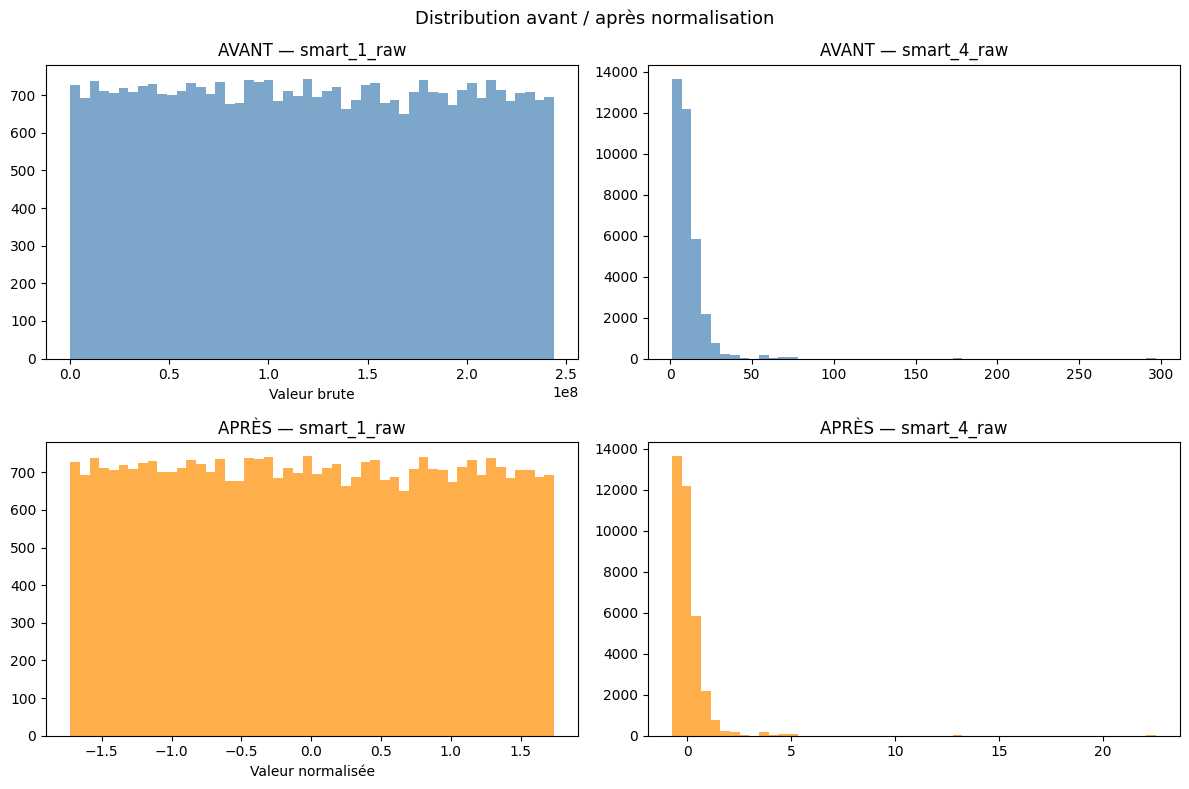

In [ ]:
# ÉTAPE 6 — Visualisation avant / après normalisation
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Avant
axes[0,0].hist(X_train_np[:,0], bins=50, color='steelblue', alpha=0.7)
axes[0,0].set_title(f'AVANT — {feature_cols[0]}')
axes[0,0].set_xlabel('Valeur brute')

axes[0,1].hist(X_train_np[:,1], bins=50, color='steelblue', alpha=0.7)
axes[0,1].set_title(f'AVANT — {feature_cols[1]}')

# Après
axes[1,0].hist(X_train_scaled[:,0], bins=50, color='darkorange', alpha=0.7)
axes[1,0].set_title(f'APRÈS — {feature_cols[0]}')
axes[1,0].set_xlabel('Valeur normalisée')

axes[1,1].hist(X_train_scaled[:,1], bins=50, color='darkorange', alpha=0.7)
axes[1,1].set_title(f'APRÈS — {feature_cols[1]}')

plt.suptitle('Distribution avant / après normalisation', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR + 'normalisation_comparison.png', dpi=100)
plt.show()